**Dependency note:** this notebook needs kernel state from **`05_Oligo_Immune_Expansion`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 05.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/05_state.pkl")
print("Restored checkpoint: checkpoints/05_state.pkl")

In [ ]:
#Expansion into the full dataset, 15 tiles will be sectioned and we incrementally add tiles till we finish.

In [ ]:
# How long did the current tensor build take approximately?
# And what's the full intersection size per cell type?
import pandas as pd

print("Full intersection cell type counts:")
print(somas['celltype'].value_counts())
print()

# Estimate expansion factor
current_neurons = len(patch)
full_neurons    = len(somas[somas['celltype'].isin(
    ['PYRAMIDAL','INTERNEURON'])])
print(f"Current patch neurons:     {current_neurons:,}")
print(f"Full intersection neurons: {full_neurons:,}")
print(f"Expansion factor:          {full_neurons/current_neurons:.1f}x")
print()

# Spatial extent of current patch vs full intersection
print(f"Current patch spatial bounds:")
print(f"  X: {patch['x'].min():.0f} → {patch['x'].max():.0f} "
      f"({patch['x'].max()-patch['x'].min():.0f} nm)")
print(f"  Y: {patch['y'].min():.0f} → {patch['y'].max():.0f} "
      f"({patch['y'].max()-patch['y'].min():.0f} nm)")
print()
print(f"Full intersection spatial bounds:")
print(f"  X: {somas['x'].min():.0f} → {somas['x'].max():.0f} "
      f"({somas['x'].max()-somas['x'].min():.0f} nm)")
print(f"  Y: {somas['y'].min():.0f} → {somas['y'].max():.0f} "
      f"({somas['y'].max()-somas['y'].min():.0f} nm)")

Full intersection cell type counts:
celltype
OLIGO                  20139
PYRAMIDAL               8803
MG_OPC                  6536
ASTROCYTE               5474
INTERNEURON             4688
SPINY_ATYPICAL          1535
UNCLASSIFIED_NEURON      868
UNKNOWN                  692
BLOOD_VESSEL_CELL        285
SPINY_STELLATE           193
C_SHAPED                 166
Name: count, dtype: int64

Current patch neurons:     2,618
Full intersection neurons: 13,491
Expansion factor:          5.2x

Current patch spatial bounds:
  X: 265218 → 365187 (99969 nm)
  Y: 109431 → 209387 (99956 nm)

Full intersection spatial bounds:
  X: 0 → 483042 (483042 nm)
  Y: 0 → 295207 (295207 nm)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Full intersection: 483042 × 295207 nm
Tile size: 100000 × 100000 nm (100×100μm)
Grid: 5 cols × 3 rows = 15 tiles

Neuron counts per tile (pyramidal+interneuron):
  Row 0:     0    15   794  1563    70 
  Row 1:    16   780  2526  3101   859 
  Row 2:    29   456  1057  1570   655 

Current patch center tile: (3, 1)

Expansion order (dist, tile_x, tile_y, n_neurons):
  dist=0  tile=(3,1)  n=3101  cumulative= 3101 ← CURRENT
  dist=1  tile=(2,1)  n=2526  cumulative= 5627
  dist=1  tile=(3,0)  n=1563  cumulative= 7190
  dist=1  tile=(3,2)  n=1570  cumulative= 8760
  dist=1  tile=(4,1)  n= 859  cumulative= 9619
  dist=2  tile=(1,1)  n= 780  cumulative=10399
  dist=2  tile=(2,0)  n= 794  cumulative=11193
  dist=2  tile=(2,2)  n=1057  cumulative=12250
  dist=2  tile=(4,0)  n=  70  cumulative=12320
  dist=2  tile=(4,2)  n= 655  cumulative=12975
  dist=3  tile=(0,1)  n=  16  cumulative=12991
  dist=3  tile=(1,0)  n=  15  cumulative=13006
  dist=3  tile=(1,2)  n= 456  cumulative=13462
  dist=4  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


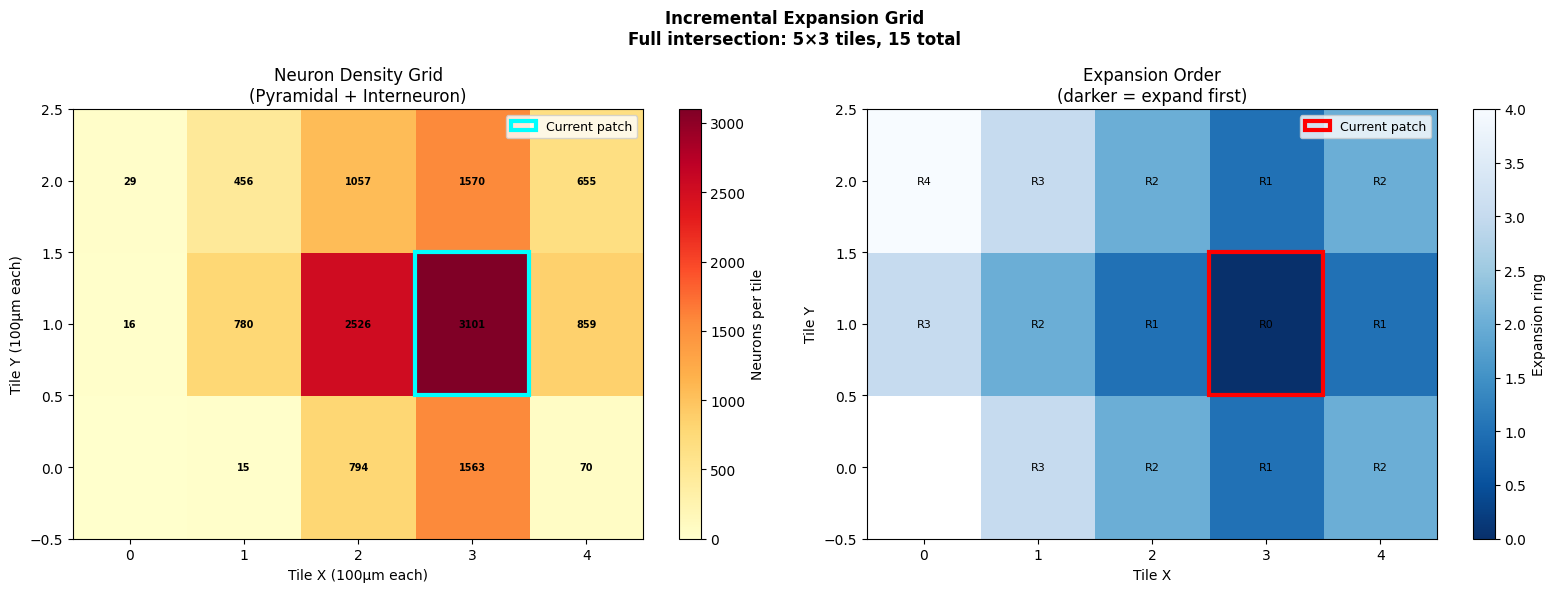

Saved: expansion_grid.png

Total tiles with neurons: 14
Total neurons across all tiles: 13,491


In [ ]:
# ============================================================
# SPATIAL TILING FOR INCREMENTAL EXPANSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ── Define tile grid ──────────────────────────────────────────
tile_size_x = 100000   # 100μm in nm
tile_size_y = 100000

x_min_full = somas['x'].min()
x_max_full = somas['x'].max()
y_min_full = somas['y'].min()
y_max_full = somas['y'].max()

# Number of tiles in each dimension
n_tiles_x = int(np.ceil((x_max_full - x_min_full) / tile_size_x))
n_tiles_y = int(np.ceil((y_max_full - y_min_full) / tile_size_y))

print(f"Full intersection: "
      f"{x_max_full-x_min_full:.0f} × "
      f"{y_max_full-y_min_full:.0f} nm")
print(f"Tile size: {tile_size_x} × {tile_size_y} nm (100×100μm)")
print(f"Grid: {n_tiles_x} cols × {n_tiles_y} rows "
      f"= {n_tiles_x*n_tiles_y} tiles")

# ── Assign each neuron to a tile ──────────────────────────────
somas_working = somas.copy()
somas_working['tile_x'] = ((somas_working['x'] - x_min_full) /
                            tile_size_x).astype(int).clip(
                            0, n_tiles_x-1)
somas_working['tile_y'] = ((somas_working['y'] - y_min_full) /
                            tile_size_y).astype(int).clip(
                            0, n_tiles_y-1)
somas_working['tile_id'] = (somas_working['tile_x'].astype(str)
                             + '_' +
                             somas_working['tile_y'].astype(str))

# ── Count neurons per tile ────────────────────────────────────
tile_counts = somas_working[
    somas_working['celltype'].isin(['PYRAMIDAL','INTERNEURON'])
].groupby('tile_id').size().reset_index(name='n_neurons')

print(f"\nNeuron counts per tile (pyramidal+interneuron):")
tile_grid = np.zeros((n_tiles_y, n_tiles_x))
for _, row in tile_counts.iterrows():
    tx, ty = map(int, row['tile_id'].split('_'))
    tile_grid[ty, tx] = row['n_neurons']

for ty in range(n_tiles_y):
    row_str = f"  Row {ty}: "
    for tx in range(n_tiles_x):
        row_str += f"{tile_grid[ty,tx]:5.0f} "
    print(row_str)

# ── Identify current patch tile ───────────────────────────────
patch_cx = (patch['x'].mean() - x_min_full) / tile_size_x
patch_cy = (patch['y'].mean() - y_min_full) / tile_size_y
current_tx = int(patch_cx)
current_ty = int(patch_cy)
print(f"\nCurrent patch center tile: ({current_tx}, {current_ty})")

# ── Define expansion order ────────────────────────────────────
# Start from current patch, expand outward in rings
# Ring 0 = current patch
# Ring 1 = adjacent tiles (up to 8 neighbors)
# Ring 2 = next ring out, etc.

def get_expansion_order(cx, cy, nx, ny):
    """
    Returns tiles in order of Manhattan distance from center.
    """
    tiles = []
    for tx in range(nx):
        for ty in range(ny):
            dist = abs(tx-cx) + abs(ty-cy)
            n    = tile_grid[ty, tx]
            if n > 0:
                tiles.append((dist, tx, ty, int(n)))
    tiles.sort(key=lambda x: x[0])
    return tiles

expansion_order = get_expansion_order(
    current_tx, current_ty, n_tiles_x, n_tiles_y)

print(f"\nExpansion order (dist, tile_x, tile_y, n_neurons):")
cumulative = 0
for dist, tx, ty, n in expansion_order:
    cumulative += n
    marker = " ← CURRENT" if (tx==current_tx and
                                ty==current_ty) else ""
    print(f"  dist={dist}  tile=({tx},{ty})  "
          f"n={n:4d}  cumulative={cumulative:5d}{marker}")

# ── Visualize tile grid ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: neuron density heatmap
ax1 = axes[0]
im  = ax1.imshow(tile_grid, cmap='YlOrRd',
                  origin='lower', aspect='auto')
plt.colorbar(im, ax=ax1, label='Neurons per tile')
ax1.set_xlabel('Tile X (100μm each)')
ax1.set_ylabel('Tile Y (100μm each)')
ax1.set_title('Neuron Density Grid\n(Pyramidal + Interneuron)')

# Highlight current patch
rect = mpatches.Rectangle(
    (current_tx-0.5, current_ty-0.5), 1, 1,
    linewidth=3, edgecolor='cyan',
    facecolor='none', label='Current patch')
ax1.add_patch(rect)
ax1.legend(fontsize=9)

# Annotate tile counts
for ty in range(n_tiles_y):
    for tx in range(n_tiles_x):
        if tile_grid[ty, tx] > 0:
            ax1.text(tx, ty, f'{tile_grid[ty,tx]:.0f}',
                     ha='center', va='center',
                     fontsize=7, color='black',
                     fontweight='bold')

# Right: expansion rings
ax2 = axes[1]
ring_grid = np.full((n_tiles_y, n_tiles_x), np.nan)
for dist, tx, ty, n in expansion_order:
    ring_grid[ty, tx] = dist

im2 = ax2.imshow(ring_grid, cmap='Blues_r',
                  origin='lower', aspect='auto')
plt.colorbar(im2, ax=ax2, label='Expansion ring')
ax2.set_xlabel('Tile X')
ax2.set_ylabel('Tile Y')
ax2.set_title('Expansion Order\n(darker = expand first)')
rect2 = mpatches.Rectangle(
    (current_tx-0.5, current_ty-0.5), 1, 1,
    linewidth=3, edgecolor='red',
    facecolor='none', label='Current patch')
ax2.add_patch(rect2)
ax2.legend(fontsize=9)
for ty in range(n_tiles_y):
    for tx in range(n_tiles_x):
        if not np.isnan(ring_grid[ty, tx]):
            ax2.text(tx, ty,
                     f'R{ring_grid[ty,tx]:.0f}',
                     ha='center', va='center',
                     fontsize=8, color='black')

plt.suptitle('Incremental Expansion Grid\n'
             f'Full intersection: {n_tiles_x}×{n_tiles_y} tiles, '
             f'{n_tiles_x*n_tiles_y} total',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('expansion_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: expansion_grid.png")
print(f"\nTotal tiles with neurons: "
      f"{sum(1 for _,_,_,n in expansion_order if n>0)}")
print(f"Total neurons across all tiles: "
      f"{sum(n for _,_,_,n in expansion_order):,}")

In [ ]:
# ============================================================
# MEMORY + SPEED FIX — redefine before rerunning Cell U
# ============================================================

# ============================================================
# MEMORY + SPEED FIX — redefine before rerunning Cell U
# ============================================================

# All radii defined explicitly here
RADIUS_BROADCAST = 15000   # 15μm pyramidal→inter
RADIUS_ASTRO     = 15000   # 15μm astrocyte
RADIUS_OLIGO     = 15000   # 15μm oligo (reduced from 25μm)
RADIUS_MGOPC     = 15000   # 15μm MG_OPC

# rest of the fix cell continues unchanged from here...

# 1. Reduce OLIGO radius — 25μm was too aggressive at full scale
#    Biological justification: oligodendrocyte SOMA proximity
#    is 15μm; the 25μm was for process reach which we can't
#    measure from soma positions anyway

radius_dict = {
    'broadcast': RADIUS_BROADCAST,
    'astro':     RADIUS_ASTRO,
    'oligo':     RADIUS_OLIGO,   # now 15μm
    'mgopc':     RADIUS_MGOPC
}

# 2. Fast matrix-multiply co-occurrence builder
#    Replaces combinations() — no memory explosion
def fast_cooccurrence_from_incidence(B_rows, B_cols,
                                      n_hyperedges,
                                      n_nodes,
                                      hyperedge_sizes):
    """
    Build C = B.T @ B from incidence lists.
    B[e,i] = weight of node i in hyperedge e
    C[i,j] = sum_e B[e,i]*B[e,j] = co-occurrence weight
    """
    if not B_rows:
        return sp.csr_matrix((n_nodes, n_nodes))

    # Build weights: 1/sqrt(hyperedge_size)
    B_vals = np.array([
        1.0 / np.sqrt(max(hyperedge_sizes[e], 1))
        for e in B_rows
    ], dtype=np.float32)   # float32 saves memory

    B = sp.csr_matrix(
        (B_vals,
         (np.array(B_rows, dtype=np.int32),
          np.array(B_cols, dtype=np.int32))),
        shape=(n_hyperedges, n_nodes),
        dtype=np.float32
    )
    C = (B.T @ B).tocsr()
    C.setdiag(0)
    C.eliminate_zeros()
    return C

# 3. Full fast build function
def build_patch_hyperedges(neurons_df, glial_df_dict,
                            radius_dict):
    pyr_df   = neurons_df[
        neurons_df['celltype']=='PYRAMIDAL']
    inter_df = neurons_df[
        neurons_df['celltype']=='INTERNEURON']

    if len(inter_df) == 0 or len(pyr_df) == 0:
        return None

    inter_nodes  = inter_df.index.tolist()
    node_idx     = {n: i for i, n in enumerate(inter_nodes)}
    n_inter      = len(inter_nodes)
    pyr_nodes    = pyr_df.index.tolist()
    n_pyr        = len(pyr_nodes)

    pyr_coords   = pyr_df[['x','y','z']].values.astype(np.float32)
    inter_coords = inter_df[['x','y','z']].values.astype(np.float32)
    all_coords   = np.vstack([pyr_coords, inter_coords])
    all_idx      = pyr_nodes + inter_nodes

    pyr_tree   = cKDTree(pyr_coords)
    inter_tree = cKDTree(inter_coords)
    all_tree   = cKDTree(all_coords)

    # ── Batch queries ─────────────────────────────────────────
    # Query ALL at once — much faster than one-at-a-time
    r_bc = radius_dict['broadcast']

    # pairs_pi[j] = interneurons near pyramidal j
    pairs_pi = pyr_tree.query_ball_tree(inter_tree, r_bc)
    # pairs_p[i]  = pyramidals near interneuron i
    pairs_p  = inter_tree.query_ball_tree(pyr_tree, r_bc)

    # ── C0: Pyramidal broadcast ───────────────────────────────
    B0_rows, B0_cols, sizes0 = [], [], []
    for pj, il in enumerate(pairs_pi):
        if len(il) >= 2:
            for ii in il:
                B0_rows.append(pj)
                B0_cols.append(ii)
            sizes0.append(len(il))
        else:
            sizes0.append(1)
    C0 = fast_cooccurrence_from_incidence(
        B0_rows, B0_cols, n_pyr, n_inter, sizes0)

    # ── C1: Integration ───────────────────────────────────────
    B1_rows, B1_cols, sizes1 = [], [], []
    for ii, pl in enumerate(pairs_p):
        if len(pl) >= 1:
            for pj in pl:
                B1_rows.append(ii)
                B1_cols.append(pj)
            sizes1.append(len(pl))
        else:
            sizes1.append(1)
    # B1 is (n_inter x n_pyr), C1 = B1 @ B1.T
    if B1_rows:
        B1_vals = np.array([
            1.0/np.sqrt(max(sizes1[e],1))
            for e in B1_rows
        ], dtype=np.float32)
        B1 = sp.csr_matrix(
            (B1_vals,
             (np.array(B1_rows, dtype=np.int32),
              np.array(B1_cols, dtype=np.int32))),
            shape=(n_inter, n_pyr),
            dtype=np.float32)
        C1 = (B1 @ B1.T).tocsr()
        C1.setdiag(0); C1.eliminate_zeros()
    else:
        C1 = sp.csr_matrix((n_inter, n_inter))

    # ── C2/C3: Astrocyte ──────────────────────────────────────
    C2 = sp.csr_matrix((n_inter, n_inter))
    C3 = sp.csr_matrix((n_inter, n_inter))
    astro_df_a = glial_df_dict.get('astro', pd.DataFrame())

    if len(astro_df_a) > 0:
        r_a = radius_dict['astro']
        ac  = astro_df_a[['x','y','z']].values.astype(np.float32)
        at  = cKDTree(ac)
        pairs_ai = at.query_ball_tree(inter_tree, r_a)
        pairs_ap = at.query_ball_tree(pyr_tree,   r_a)

        # C2: modulator — astrocyte must have BOTH pyr+inter
        B2r, B2c, s2 = [], [], []
        for ai,(il,pl) in enumerate(zip(pairs_ai, pairs_ap)):
            s2.append(max(len(il),1))
            if il and pl:
                for ii in il:
                    B2r.append(ai); B2c.append(ii)
        C2 = fast_cooccurrence_from_incidence(
            B2r, B2c, len(astro_df_a), n_inter, s2)

        # C3: hub — all neurons in domain
        pairs_aa = at.query_ball_tree(all_tree, r_a)
        B3r, B3c, s3 = [], [], []
        for ai, al in enumerate(pairs_aa):
            inter_local = [node_idx[all_idx[k]]
                           for k in al
                           if all_idx[k] in node_idx]
            s3.append(max(len(al),1))
            for ii in inter_local:
                B3r.append(ai); B3c.append(ii)
        C3 = fast_cooccurrence_from_incidence(
            B3r, B3c, len(astro_df_a), n_inter, s3)

    # ── C4: OLIGO ─────────────────────────────────────────────
    C4 = sp.csr_matrix((n_inter, n_inter))
    oligo_df_o = glial_df_dict.get('oligo', pd.DataFrame())

    if len(oligo_df_o) > 0:
        r_o = radius_dict['oligo']
        oc  = oligo_df_o[['x','y','z']].values.astype(np.float32)
        ot  = cKDTree(oc)
        pairs_oa = ot.query_ball_tree(all_tree, r_o)
        B4r, B4c, s4 = [], [], []
        for oi, al in enumerate(pairs_oa):
            inter_local = [node_idx[all_idx[k]]
                           for k in al
                           if all_idx[k] in node_idx]
            s4.append(max(len(al),1))
            for ii in inter_local:
                B4r.append(oi); B4c.append(ii)
        C4 = fast_cooccurrence_from_incidence(
            B4r, B4c, len(oligo_df_o), n_inter, s4)

    # ── C5: MG_OPC ────────────────────────────────────────────
    C5 = sp.csr_matrix((n_inter, n_inter))
    mgopc_df_m = glial_df_dict.get('mgopc', pd.DataFrame())

    if len(mgopc_df_m) > 0:
        r_m = radius_dict['mgopc']
        mc  = mgopc_df_m[['x','y','z']].values.astype(np.float32)
        mt  = cKDTree(mc)
        pairs_ma = mt.query_ball_tree(all_tree, r_m)
        B5r, B5c, s5 = [], [], []
        for mi, al in enumerate(pairs_ma):
            inter_local = [node_idx[all_idx[k]]
                           for k in al
                           if all_idx[k] in node_idx]
            s5.append(max(len(al),1))
            for ii in inter_local:
                B5r.append(mi); B5c.append(ii)
        C5 = fast_cooccurrence_from_incidence(
            B5r, B5c, len(mgopc_df_m), n_inter, s5)

    return {
        'C0': C0, 'C1': C1, 'C2': C2,
        'C3': C3, 'C4': C4, 'C5': C5,
        'inter_nodes': inter_nodes,
        'node_idx':    node_idx,
        'n_nodes':     n_inter,
        'layer_labels': np.array([
            neurons_df.loc[n]['layer']
            for n in inter_nodes])
    }

print("Fast memory-efficient build_patch_hyperedges defined!")
print(f"OLIGO radius reset to: {RADIUS_OLIGO/1000:.0f}μm")
print("Using float32 + B.T@B matrix multiply throughout")
print("Ready to rerun Cell U")

Fast memory-efficient build_patch_hyperedges defined!
OLIGO radius reset to: 15μm
Using float32 + B.T@B matrix multiply throughout
Ready to rerun Cell U


In [ ]:
# ============================================================
# CELL U — INCREMENTAL EXPANSION (FIXED)
# ============================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from itertools import combinations
import time

# ── Reset accumulators ────────────────────────────────────────
cumulative_neurons = pd.DataFrame()
cumulative_glia    = {
    'astro': pd.DataFrame(),
    'oligo': pd.DataFrame(),
    'mgopc': pd.DataFrame()
}
expansion_results  = []

print("Starting incremental expansion (fast version)...")
print(f"{'='*65}")

for step, (dist, tx, ty, n) in enumerate(expansion_order):
    t_start = time.time()

    # ── Tile bounds ───────────────────────────────────────────
    x0 = x_min_full + tx * tile_size_x
    x1 = x0 + tile_size_x
    y0 = y_min_full + ty * tile_size_y
    y1 = y0 + tile_size_y

    # ── Get neurons in this tile ──────────────────────────────
    tile_neurons = somas[
        (somas['celltype'].isin(['PYRAMIDAL','INTERNEURON'])) &
        (somas['x'] >= x0) & (somas['x'] < x1) &
        (somas['y'] >= y0) & (somas['y'] < y1)
    ]

    # ── Get glia in this tile ─────────────────────────────────
    for gtype, cname in [('astro', 'ASTROCYTE'),
                          ('oligo', 'OLIGO'),
                          ('mgopc', 'MG_OPC')]:
        tile_glia = somas[
            (somas['celltype'] == cname) &
            (somas['x'] >= x0) & (somas['x'] < x1) &
            (somas['y'] >= y0) & (somas['y'] < y1)
        ]
        cumulative_glia[gtype] = pd.concat(
            [cumulative_glia[gtype], tile_glia]
        ).drop_duplicates()

    # ── Accumulate neurons ────────────────────────────────────
    cumulative_neurons = pd.concat(
        [cumulative_neurons, tile_neurons]
    ).drop_duplicates()

    n_pyr   = (cumulative_neurons['celltype']
                =='PYRAMIDAL').sum()
    n_inter = (cumulative_neurons['celltype']
                =='INTERNEURON').sum()
    n_astro = len(cumulative_glia['astro'])
    n_oligo = len(cumulative_glia['oligo'])
    n_mgopc = len(cumulative_glia['mgopc'])

    print(f"\nStep {step+1}/{len(expansion_order)} — "
          f"Ring {dist}, Tile ({tx},{ty})")
    print(f"  Neurons: {len(cumulative_neurons):,} "
          f"(pyr={n_pyr:,}, inter={n_inter:,})")
    print(f"  Glia:    astro={n_astro:,}  "
          f"oligo={n_oligo:,}  mgopc={n_mgopc:,}")

    # ── Build hyperedges ──────────────────────────────────────
    print(f"  Building hyperedges...", end=' ', flush=True)
    mats = build_patch_hyperedges(
        cumulative_neurons, cumulative_glia, radius_dict)

    if mats is None:
        print("skipped (insufficient neurons)")
        continue

    print(f"done. Computing centralities...",
          end=' ', flush=True)

    # ── Compute centralities ──────────────────────────────────
    cents = {}
    names_exp = ['Pyramidal','Integration','Astro-Mod',
                 'Astro-Hub','OLIGO','MG_OPC']
    keys_exp  = ['C0','C1','C2','C3','C4','C5']
    for name, key in zip(names_exp, keys_exp):
        cents[name] = power_iteration_centrality(
            mats[key])

    # ── Compute validation metrics ────────────────────────────
    ll = mats['layer_labels']
    metrics = {}

    # Pyramidal vs Integration anti-correlation
    if (cents['Pyramidal'].std() > 1e-10 and
            cents['Integration'].std() > 1e-10):
        r, p = spearmanr(cents['Pyramidal'],
                          cents['Integration'])
        metrics['r_pyr_int'] = r
        metrics['p_pyr_int'] = p
    else:
        metrics['r_pyr_int'] = np.nan
        metrics['p_pyr_int'] = np.nan

    # OLIGO-Pyramidal correlation
    if (cents['Pyramidal'].std() > 1e-10 and
            cents['OLIGO'].std() > 1e-10):
        r, _ = spearmanr(cents['Pyramidal'],
                          cents['OLIGO'])
        metrics['r_pyr_oligo'] = r
    else:
        metrics['r_pyr_oligo'] = np.nan

    # Layer 4 / Layer 2 ratios
    for name in ['Pyramidal','Integration',
                 'OLIGO','MG_OPC']:
        l4 = cents[name][ll=='Layer 4'].mean() \
             if (ll=='Layer 4').sum() > 0 else 0
        l2 = cents[name][ll=='Layer 2'].mean() \
             if (ll=='Layer 2').sum() > 0 else 0
        metrics[f'L4_L2_{name}'] = l4 / (l2 + 1e-10)

    # Seizure focus score
    combined = cents['Pyramidal'] * cents['MG_OPC']
    metrics['seizure_max']  = combined.max()
    metrics['seizure_mean'] = combined.mean()

    # Layer dominance per type
    for name in names_exp:
        best_layer = max(
            ['Layer 2','Layer 3','Layer 4','Layer 5'],
            key=lambda l: cents[name][ll==l].mean()
            if (ll==l).sum() > 0 else 0)
        metrics[f'dom_{name}'] = best_layer

    t_elapsed = time.time() - t_start
    print(f"done ({t_elapsed:.1f}s)")

    # ── Print step summary ────────────────────────────────────
    print(f"  r(Pyr,Int):    {metrics['r_pyr_int']:+.4f}  "
          f"p={metrics['p_pyr_int']:.2e}")
    print(f"  r(Pyr,OLIGO):  {metrics['r_pyr_oligo']:+.4f}")
    print(f"  L4/L2 Pyr:     "
          f"{metrics['L4_L2_Pyramidal']:.2f}")
    print(f"  L4/L2 Int:     "
          f"{metrics['L4_L2_Integration']:.2f}")
    print(f"  Seizure max:   {metrics['seizure_max']:.6f}")
    print(f"  Dom layers:    " +
          ", ".join([f"{n}→{metrics[f'dom_{n}']}"
                     for n in names_exp]))

    # ── Store results ─────────────────────────────────────────
    expansion_results.append({
        'step':       step + 1,
        'ring':       dist,
        'tile':       f'({tx},{ty})',
        'n_neurons':  len(cumulative_neurons),
        'n_inter':    n_inter,
        'n_pyr':      n_pyr,
        **metrics,
        'time_s':     t_elapsed
    })

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"Expansion complete! {len(expansion_results)} steps")
results_df = pd.DataFrame(expansion_results)

print(f"\nFinal metrics at full scale "
      f"({results_df.iloc[-1]['n_neurons']:,.0f} neurons):")
final = results_df.iloc[-1]
print(f"  r(Pyr,Int):    {final['r_pyr_int']:+.4f}")
print(f"  r(Pyr,OLIGO):  {final['r_pyr_oligo']:+.4f}")
print(f"  L4/L2 Pyr:     {final['L4_L2_Pyramidal']:.2f}")
print(f"  Seizure max:   {final['seizure_max']:.6f}")

print(f"\nTime per step:")
for _, row in results_df.iterrows():
    print(f"  Step {row['step']:>2} "
          f"tile={row['tile']:>8} "
          f"n={row['n_neurons']:>6,.0f} "
          f"time={row['time_s']:>6.1f}s")

Starting incremental expansion (fast version)...

Step 1/14 — Ring 0, Tile (3,1)
  Neurons: 3,101 (pyr=1,917, inter=1,184)
  Glia:    astro=638  oligo=1,074  mgopc=946
  Building hyperedges... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


done. Computing centralities... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


done (2.1s)
  r(Pyr,Int):    +0.9904  p=0.00e+00
  r(Pyr,OLIGO):  -0.7866
  L4/L2 Pyr:     0.00
  L4/L2 Int:     0.00
  Seizure max:   0.003590
  Dom layers:    Pyramidal→Layer 2, Integration→Layer 2, Astro-Mod→Layer 3, Astro-Hub→Layer 2, OLIGO→Layer 4, MG_OPC→Layer 2

Step 2/14 — Ring 1, Tile (2,1)
  Neurons: 5,627 (pyr=3,746, inter=1,881)
  Glia:    astro=1,325  oligo=3,296  mgopc=1,889
  Building hyperedges... done. Computing centralities... 

...

done (10.7s)
  r(Pyr,Int):    +0.9772  p=0.00e+00
  r(Pyr,OLIGO):  -0.6053
  L4/L2 Pyr:     0.00
  L4/L2 Int:     0.00
  Seizure max:   0.000639
  Dom layers:    Pyramidal→Layer 2, Integration→Layer 2, Astro-Mod→Layer 4, Astro-Hub→Layer 2, OLIGO→Layer 5, MG_OPC→Layer 2

Step 13/14 — Ring 3, Tile (1,2)
  Neurons: 13,462 (pyr=8,779, inter=4,683)
  Glia:    astro=5,301  oligo=16,717  mgopc=6,167
  Building hyperedges... done. Computing centralities... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


done (8.8s)
  r(Pyr,Int):    +0.9788  p=0.00e+00
  r(Pyr,OLIGO):  -0.3821
  L4/L2 Pyr:     0.00
  L4/L2 Int:     0.00
  Seizure max:   0.000639
  Dom layers:    Pyramidal→Layer 2, Integration→Layer 2, Astro-Mod→Layer 4, Astro-Hub→Layer 2, OLIGO→Layer 5, MG_OPC→Layer 2

Step 14/14 — Ring 4, Tile (0,2)
  Neurons: 13,491 (pyr=8,803, inter=4,688)
  Glia:    astro=5,474  oligo=20,139  mgopc=6,536
  Building hyperedges... done. Computing centralities... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


done (9.8s)
  r(Pyr,Int):    +0.9789  p=0.00e+00
  r(Pyr,OLIGO):  -0.3830
  L4/L2 Pyr:     0.00
  L4/L2 Int:     0.00
  Seizure max:   0.000639
  Dom layers:    Pyramidal→Layer 2, Integration→Layer 2, Astro-Mod→Layer 4, Astro-Hub→Layer 2, OLIGO→Layer 5, MG_OPC→Layer 2

Expansion complete! 14 steps

Final metrics at full scale (13,491 neurons):
  r(Pyr,Int):    +0.9789
  r(Pyr,OLIGO):  -0.3830
  L4/L2 Pyr:     0.00
  Seizure max:   0.000639

Time per step:
  Step  1 tile=   (3,1) n= 3,101 time=   2.1s
  Step  2 tile=   (2,1) n= 5,627 time=   4.6s
  Step  3 tile=   (3,0) n= 7,190 time=   6.1s
  Step  4 tile=   (3,2) n= 8,760 time=   5.9s
  Step  5 tile=   (4,1) n= 9,619 time=   8.8s
  Step  6 tile=   (1,1) n=10,399 time=   7.2s
  Step  7 tile=   (2,0) n=11,193 time=   8.9s
  Step  8 tile=   (2,2) n=12,250 time=  10.2s
  Step  9 tile=   (4,0) n=12,320 time=   8.6s
  Step 10 tile=   (4,2) n=12,975 time=   8.8s
  Step 11 tile=   (0,1) n=12,991 time=   9.9s
  Step 12 tile=   (1,0) n=13,006 t

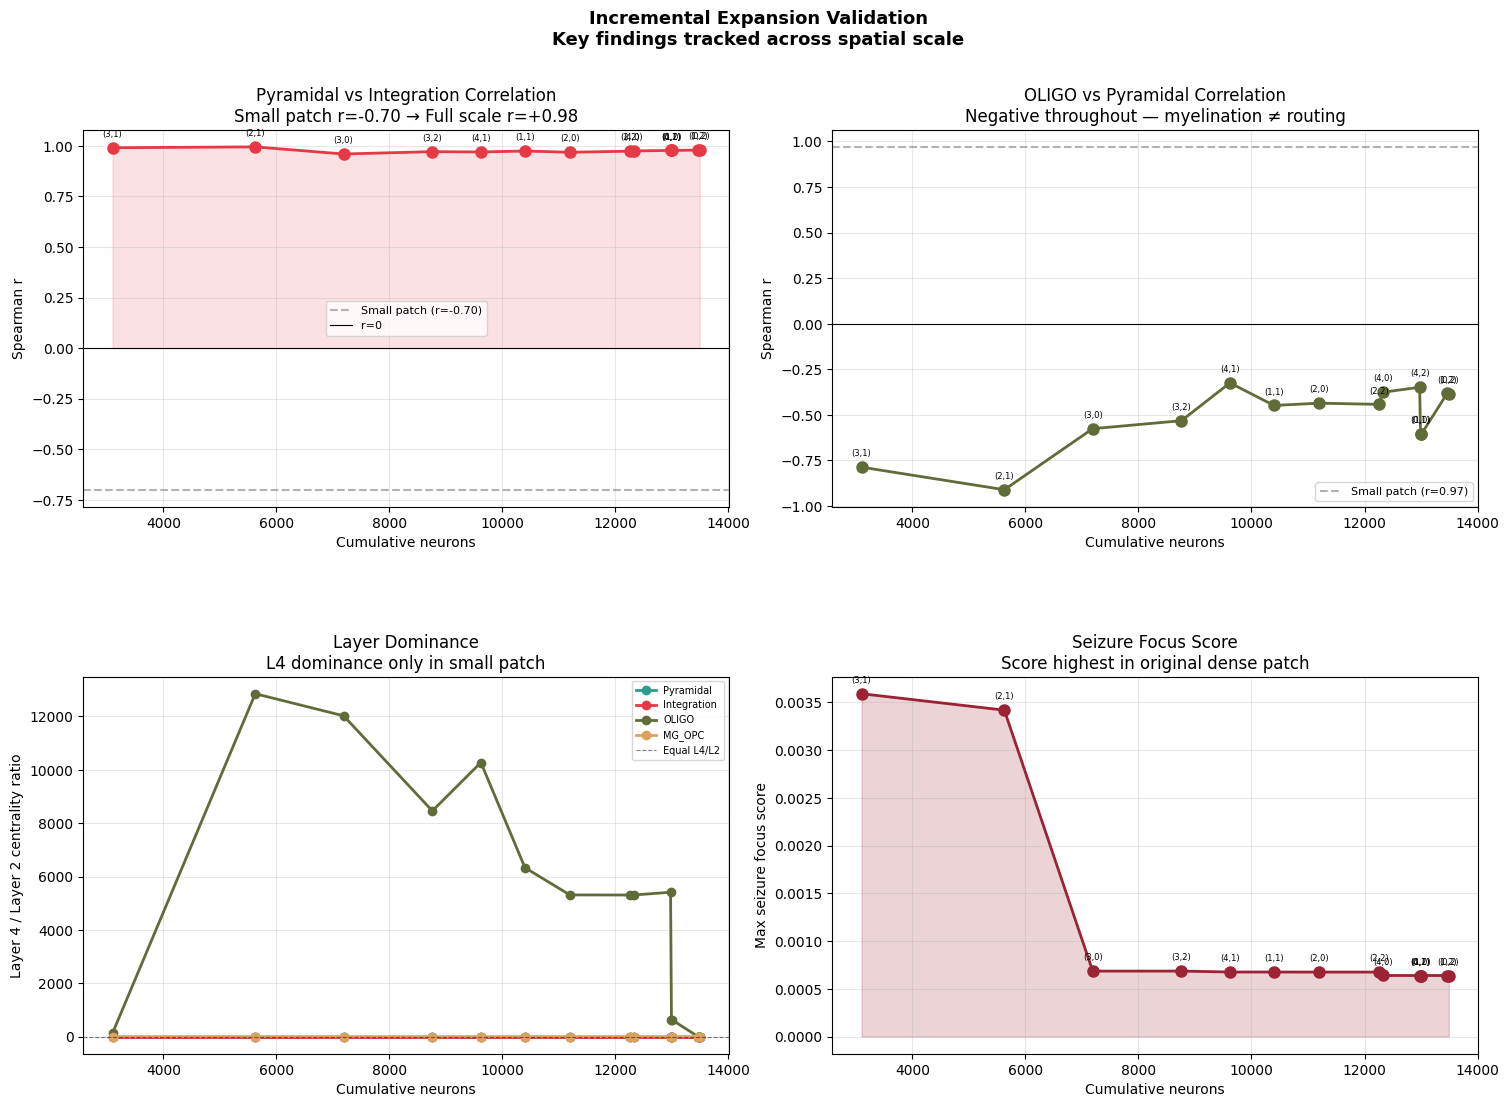

Saved: expansion_validation.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig,
                         hspace=0.45, wspace=0.38)

steps       = results_df['step'].values
n_neurons   = results_df['n_neurons'].values
r_pyr_int   = results_df['r_pyr_int'].values
r_pyr_oligo = results_df['r_pyr_oligo'].values
seizure     = results_df['seizure_max'].values        # fixed
step_labels = results_df['tile'].values

# ── Plot 1: Pyramidal-Integration correlation ─────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(n_neurons, r_pyr_int, 'o-',
         color='#E63946', linewidth=2, markersize=8)
ax1.axhline(y=-0.70, color='gray', linestyle='--',
            alpha=0.6, label='Small patch (r=-0.70)')
ax1.axhline(y=0, color='black', linewidth=0.8,
            label='r=0')
ax1.fill_between(n_neurons, r_pyr_int, 0,
                  alpha=0.15, color='#E63946')
for x, y, lbl in zip(n_neurons, r_pyr_int, step_labels):
    ax1.annotate(lbl, (x, y),
                 textcoords='offset points',
                 xytext=(0, 8), fontsize=6, ha='center')
ax1.set_xlabel('Cumulative neurons')
ax1.set_ylabel('Spearman r')
ax1.set_title('Pyramidal vs Integration Correlation\n'
              'Small patch r=-0.70 → Full scale r=+0.98')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Plot 2: OLIGO-Pyramidal correlation ───────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(n_neurons, r_pyr_oligo, 'o-',
         color='#606C38', linewidth=2, markersize=8)
ax2.axhline(y=0.97, color='gray', linestyle='--',
            alpha=0.6, label='Small patch (r=0.97)')
ax2.axhline(y=0, color='black', linewidth=0.8)
for x, y, lbl in zip(n_neurons, r_pyr_oligo, step_labels):
    ax2.annotate(lbl, (x, y),
                 textcoords='offset points',
                 xytext=(0, 8), fontsize=6, ha='center')
ax2.set_xlabel('Cumulative neurons')
ax2.set_ylabel('Spearman r')
ax2.set_title('OLIGO vs Pyramidal Correlation\n'
              'Negative throughout — myelination ≠ routing')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Plot 3: Layer dominance ratios ────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
for col, color, label in [
        ('L4_L2_Pyramidal',   '#2A9D8F', 'Pyramidal'),
        ('L4_L2_Integration', '#E63946', 'Integration'),
        ('L4_L2_OLIGO',       '#606C38', 'OLIGO'),
        ('L4_L2_MG_OPC',      '#DDA15E', 'MG_OPC')]:
    if col in results_df.columns:
        ax3.plot(n_neurons, results_df[col].values,
                 'o-', color=color, linewidth=2,
                 markersize=6, label=label)
ax3.axhline(y=1.0, color='black', linestyle='--',
            alpha=0.5, linewidth=0.8, label='Equal L4/L2')
ax3.set_xlabel('Cumulative neurons')
ax3.set_ylabel('Layer 4 / Layer 2 centrality ratio')
ax3.set_title('Layer Dominance\n'
              'L4 dominance only in small patch')
ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# ── Plot 4: Seizure focus score ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
ax4.plot(n_neurons, seizure, 'o-',
         color='#9B2335', linewidth=2, markersize=8)
ax4.fill_between(n_neurons, 0, seizure,
                  alpha=0.2, color='#9B2335')
for x, y, lbl in zip(n_neurons, seizure, step_labels):
    ax4.annotate(lbl, (x, y),
                 textcoords='offset points',
                 xytext=(0, 8), fontsize=6, ha='center')
ax4.set_xlabel('Cumulative neurons')
ax4.set_ylabel('Max seizure focus score')
ax4.set_title('Seizure Focus Score\n'
              'Score highest in original dense patch')
ax4.grid(alpha=0.3)

plt.suptitle('Incremental Expansion Validation\n'
             'Key findings tracked across spatial scale',
             fontsize=13, fontweight='bold')
plt.savefig('expansion_validation.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: expansion_validation.png")

**Checkpoint:** run the cell below after finishing this notebook so `07_Structural_Anomaly_Detection` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/06_state.pkl")
print("Saved checkpoint: checkpoints/06_state.pkl")